# radish — reading NEXRAD chunks from the live S3 stream

> **Kernel:** This notebook is pinned to the **Python (radish)** kernel (the workspace `.venv`'s Python 3.12, where `maturin develop` installed the radish editable package). If JupyterLab opens it on a different kernel and `import radish` fails, switch via *Kernel → Change Kernel… → Python (radish)*. First-time setup is one command from the workspace root:
>
> ```bash
> .venv/bin/python -m ipykernel install --user --name radish --display-name 'Python (radish)'
> ```

NOAA's `unidata-nexrad-level2-chunks` S3 bucket delivers each volume as **many small files** that arrive seconds after each scan, vs. minutes for the assembled `noaa-nexrad-level2` archive. xradar exposes [`open_nexradlevel2_datatree(list_of_bytes)`](https://docs.openradarscience.org/projects/xradar/en/stable/notebooks/nexrad_read_chunks.html) for this stream; radish now matches that contract via:

* `radish.open_datatree(input)` → `xarray.DataTree` — the canonical entry, accepts a path, raw `bytes`, a file-like, or a list of bytes/paths (chunks)
* `radish.read_nexrad_chunks(list[bytes])` → `VolumeData` — low-level building block when you want the typed `VolumeData` directly without going through xarray

Each volume directory contains three chunk types:

| chunk | role |
|---|---|
| `S` | volume header + first metadata records |
| `I00..In` | LDM-compressed sweep data, numbered in scan order |
| `E` | end-of-volume marker |

Concatenating `[S, I00, I01, ..., E]` reconstitutes a complete Archive II buffer byte-for-byte, so radish hands it to the same decoder used by `read_nexrad`. Truncated volumes (missing `E`, or only the first few `I` chunks) decode whatever rays survive — incomplete trailing sweeps come through with fewer rays than the VCP would normally produce.

This notebook walks through the workflow end-to-end, then compares against xradar to confirm parity.

## 1. Browse the live bucket

With `fsspec` + `s3fs` we can list radars and their recent volumes anonymously.

In [1]:
import fsspec

fs = fsspec.filesystem('s3', anon=True)

# A handful of radars at the top of the bucket (one dir per ICAO).
radars = [p.split('/')[-1] for p in fs.ls('unidata-nexrad-level2-chunks/')]
print(f'{len(radars)} radars in the live stream; sample: {radars[:8]}')

203 radars in the live stream; sample: ['KABR', 'KABX', 'KAKQ', 'KAMA', 'KAMX', 'KAPX', 'KARX', 'KATX']


In [2]:
# Per-radar volume directories — numbered sequentially. The most recent are
# at the end of the listing.
volumes = fs.ls('unidata-nexrad-level2-chunks/KLOT/')
print(f'KLOT has {len(volumes)} recent volumes;')
for v in volumes[-3:]:
    print(' ', v)

KLOT has 507 recent volumes;
  unidata-nexrad-level2-chunks/KLOT/791
  unidata-nexrad-level2-chunks/KLOT/792
  unidata-nexrad-level2-chunks/KLOT/793


## 2. Pick a volume and fetch its chunks

Filenames inside a volume directory follow `YYYYMMDD-HHMMSS-NNN-{S,I,E}`. The sequence number `NNN` is zero-padded so plain `sorted()` is enough to put them in scan order.

We pick the **second-most-recent** volume (the most-recent may still be filling).

In [3]:
vol_dir = volumes[-2]
chunk_paths = sorted(fs.ls(vol_dir))
n_s = sum(p.endswith('-S') for p in chunk_paths)
n_i = sum('-I' in p[-5:] for p in chunk_paths)
n_e = sum(p.endswith('-E') for p in chunk_paths)

print(f'volume:  {vol_dir}')
print(f'chunks:  {len(chunk_paths)} total  (S={n_s}, I={n_i}, E={n_e})')
print('first three:')
for p in chunk_paths[:3]:
    print(f'  {p.split(chr(47))[-1]:<32} size={fs.info(p)["size"]:>8} bytes')
print('last two:')
for p in chunk_paths[-2:]:
    print(f'  {p.split(chr(47))[-1]:<32} size={fs.info(p)["size"]:>8} bytes')

volume:  unidata-nexrad-level2-chunks/KLOT/792
chunks:  55 total  (S=1, I=53, E=1)
first three:
  20260502-222059-001-S            size=    2333 bytes
  20260502-222059-002-I            size=   76578 bytes
  20260502-222059-003-I            size=   70356 bytes
last two:
  20260502-222059-054-I            size=   32593 bytes
  20260502-222059-055-E            size=   33263 bytes


In [4]:
import time

t = time.perf_counter()
all_bytes = [fs.open(p, 'rb').read() for p in chunk_paths]
t_fetch = time.perf_counter() - t
size_mb = sum(len(b) for b in all_bytes) / 1e6
print(f'fetched {size_mb:.2f} MB in {t_fetch:.2f}s '
      f'({size_mb / t_fetch:.1f} MB/s)')

fetched 2.08 MB in 3.66s (0.6 MB/s)


## 3. Decode through radish (one-liner)

The unified `radish.open_datatree(input)` accepts the chunk list directly and returns an `xarray.DataTree` with the same shape as `xr.open_datatree(file, engine="radish")` would for an assembled volume.

In [5]:
import radish

t = time.perf_counter()
dt_radish = radish.open_datatree(all_bytes)
t_radish = time.perf_counter() - t

print(f'radish decode: {t_radish:.3f}s')
print()
print(f'ICAO            : {dt_radish.attrs["instrument_name"]}')
print(f'scan_name       : {dt_radish.attrs["scan_name"]}')
print(f'dynamic_type    : {dt_radish.attrs["dynamic_scan_type"]}')
print(f'rda_build       : {dt_radish.attrs["rda_build_number"]}')
print(f'sweeps decoded  : {sum(1 for k in dt_radish.children if k.startswith("sweep_"))}')
print(f'time_coverage   : {dt_radish["time_coverage_start"].item()} → '
      f'{dt_radish["time_coverage_end"].item()}')

radish decode: 1.031s

ICAO            : KLOT
scan_name       : VCP-35
dynamic_type    : standard
rda_build       : 2400
sweeps decoded  : 12
time_coverage   : 2026-05-02T22:20:59Z → 2026-05-02T22:27:54Z


In [6]:
dt_radish

<xarray.DataTree>
Group: /
│   Dimensions:              ()
│   Coordinates:
│       latitude             float64 8B 41.6
│       longitude            float64 8B -88.08
│       altitude             float64 8B 231.0
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2026-05-02T22:20:59Z'
│       time_coverage_end    <U20 80B '2026-05-02T22:27:54Z'
│   Attributes: (12/25)
│       instrument_name:              KLOT
│       Conventions:                  None
│       version:                      None
│       title:                        None
│       institution:                  None
│       references:                   None
│       ...                           ...
│       avset_enabled:                True
│       ebc_enabled:                  True
│       super_res_status:             2
│       rda_build_number:             2400
│       operational_mode:             4
│       actual_elevation_cuts:        12
├── Group: /sweep_0
│       Dimensions:            (azimuth: 720, range: 1832)
│       Coordinates:
│         * azimuth            (azimuth) float64 6kB 0.2527 0.7553 1.25 ... 359.3 359.7
│           elevation          (azimuth) float64 6kB 0.5273 0.5273 ... 0.5273 0.5273
│           time               (azimuth) datetime64[ns] 6kB 2026-05-02T22:21:53.05900...
│         * range              (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
│       Data variables:
│           CCORH              (azimuth, range) float64 11MB nan nan 44.0 ... nan nan
│           DBZH               (azimuth, range) float64 11MB -29.5 -27.0 ... nan nan
│           PHIDP              (azimuth, range) float64 11MB 91.32 103.0 ... nan nan
│           RHOHV              (azimuth, range) float64 11MB 0.2083 0.2083 ... nan nan
│           ZDR                (azimuth, range) float64 11MB -6.906 -7.344 ... nan nan
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 1
│           sweep_fixed_angle  float64 8B 0.5273
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│       Attributes:
│           waveform_type:          contiguous_surveillance
│           channel_config:         sz2_phase_coding
│           super_resolution:       11
│           sails_cut:              False
│           sails_sequence_number:  0
│           mrle_cut:               False
│           mrle_sequence_number:   0
│           mpda_cut:               False
│           base_tilt_cut:          False
├── Group: /sweep_1
│       Dimensions:            (azimuth: 720, range: 1192)
│       Coordinates:
│         * azimuth            (azimuth) float64 6kB 0.2087 0.6976 1.217 ... 359.2 359.7
│           elevation          (azimuth) float64 6kB 0.5273 0.5273 ... 0.5273 0.5273
│           time               (azimuth) datetime64[ns] 6kB 2026-05-02T22:22:29.98900...
│         * range              (range) float32 5kB 2.125e+03 2.375e+03 ... 2.999e+05
│       Data variables:
│           DBZH               (azimuth, range) float64 7MB -20.5 -24.5 ... nan nan
│           VRADH              (azimuth, range) float64 7MB 1.5 0.5 nan ... nan nan nan
│           WRADH              (azimuth, range) float64 7MB 2.5 5.5 nan ... nan nan nan
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 2
│           sweep_fixed_angle  float64 8B 0.5273
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│       Attributes:
│           waveform_type:          contiguous_doppler
│           channel_config:         sz2_phase_coding
│           super_resolution:       7
│           sails_cut:              False
│           sails_sequence_number:  0
│           mrle_cut:               False
│           mrle_sequence_number:   0
│           mpda_cut:               False
│           base_ti

## 4. Decode through xradar and compare

Both readers accept the same `list_of_bytes` input. The MSG_2 / MSG_5 attrs (root + per-sweep) match xradar verbatim — Phase B work merged in PR #2 — and now do so for chunked input too.

In [7]:
import xradar

t = time.perf_counter()
dt_xradar = xradar.io.open_nexradlevel2_datatree(all_bytes)
t_xradar = time.perf_counter() - t

print(f'xradar decode: {t_xradar:.3f}s')
print(f'radish decode: {t_radish:.3f}s')
print(f'speedup:       {t_xradar / t_radish:.2f}x')

xradar decode: 1.162s
radish decode: 1.031s
speedup:       1.13x


In [8]:
# Root attribute parity check — same 16 keys + same Python types/values.
ROOT_KEYS = (
    'dynamic_scan_type', 'mpda_vcp', 'base_tilt_vcp', 'num_base_tilts',
    'vcp_truncated', 'vcp_sequence_active', 'number_elevation_cuts',
    'doppler_velocity_resolution', 'vcp_pulse_width',
    'avset_enabled', 'ebc_enabled', 'super_res_status',
    'rda_build_number', 'operational_mode', 'actual_elevation_cuts',
    'scan_name',
)

print(f'{"attr":<32}{"radish":<28}{"xradar":<28}match')
print('-' * 95)
for k in ROOT_KEYS:
    r = dt_radish.attrs.get(k, '<missing>')
    x = dt_xradar.attrs.get(k, '<missing>')
    mark = '✓' if r == x else '✗'
    print(f'{k:<32}{f"{r!r}":<28}{f"{x!r}":<28}{mark}')

attr                            radish                      xradar                      match
-----------------------------------------------------------------------------------------------
dynamic_scan_type               'standard'                  'standard'                  ✓
mpda_vcp                        False                       False                       ✓
base_tilt_vcp                   False                       False                       ✓
num_base_tilts                  0                           0                           ✓
vcp_truncated                   False                       False                       ✓
vcp_sequence_active             False                       False                       ✓
number_elevation_cuts           12                          12                          ✓
doppler_velocity_resolution     0.5                         0.5                         ✓
vcp_pulse_width                 'short'                     'short'                     ✓


In [9]:
# Per-sweep attribute parity, sampling 3 sweeps for variety.
SWEEP_KEYS = (
    'waveform_type', 'channel_config', 'super_resolution',
    'sails_cut', 'sails_sequence_number',
    'mrle_cut', 'mrle_sequence_number',
    'mpda_cut', 'base_tilt_cut',
)

sweep_keys = sorted(k for k in dt_radish.children if k.startswith('sweep_'))
sample = [sweep_keys[0], sweep_keys[len(sweep_keys) // 2], sweep_keys[-1]]

mismatches = 0
for skey in sample:
    print(f'=== {skey} ===')
    rs = dt_radish[skey].attrs
    xs = dt_xradar[skey].attrs
    print(f'{"attr":<26}{"radish":<26}{"xradar":<26}match')
    print('-' * 84)
    for k in SWEEP_KEYS:
        r = rs.get(k, '<missing>')
        x = xs.get(k, '<missing>')
        mark = '✓' if r == x else '✗'
        if mark == '✗':
            mismatches += 1
        print(f'{k:<26}{f"{r!r}":<26}{f"{x!r}":<26}{mark}')
    print()

# Aggregate over all sweeps.
total_mismatches = 0
for skey in sweep_keys:
    rs = dt_radish[skey].attrs
    xs = dt_xradar[skey].attrs
    for k in SWEEP_KEYS:
        if k in xs and rs.get(k) != xs[k]:
            total_mismatches += 1
print(f'aggregate: {len(sweep_keys)} sweeps × {len(SWEEP_KEYS)} attrs = '
      f'{len(sweep_keys) * len(SWEEP_KEYS)} pairs, mismatches: {total_mismatches}')

=== sweep_0 ===
attr                      radish                    xradar                    match
------------------------------------------------------------------------------------
waveform_type             'contiguous_surveillance' 'contiguous_surveillance' ✓
channel_config            'sz2_phase_coding'        'sz2_phase_coding'        ✓
super_resolution          11                        11                        ✓
sails_cut                 False                     False                     ✓
sails_sequence_number     0                         0                         ✓
mrle_cut                  False                     False                     ✓
mrle_sequence_number      0                         0                         ✓
mpda_cut                  False                     False                     ✓
base_tilt_cut             False                     False                     ✓

=== sweep_4 ===
attr                      radish                    xradar                    

## 5. Plot a sweep

The DataTree carries `xradar`'s standard accessor (`georeference`), so plotting is one line.

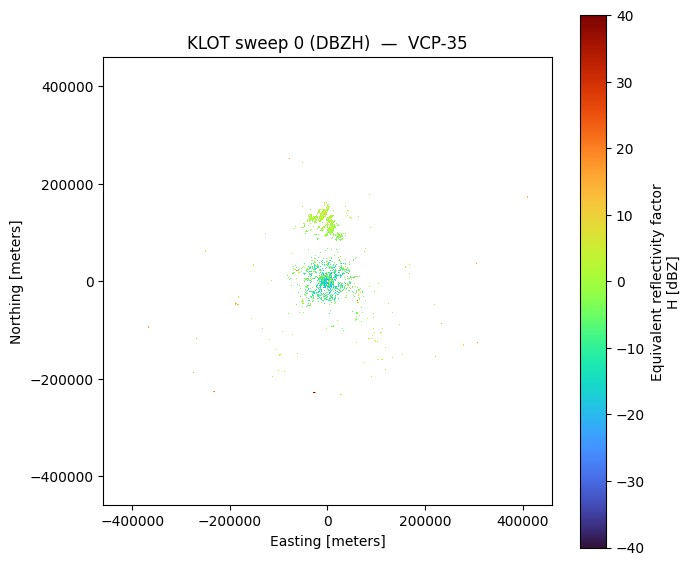

In [10]:
import matplotlib.pyplot as plt

s0 = dt_radish['/sweep_0'].to_dataset(inherit='all_coords').xradar.georeference()
moment = 'DBZH' if 'DBZH' in s0.data_vars else next(iter(s0.data_vars))

fig, ax = plt.subplots(figsize=(7, 6))
s0[moment].plot(x='x', y='y', ax=ax,
                cmap='turbo' if moment == 'DBZH' else 'viridis')
ax.set_aspect('equal')
ax.set_title(
    f'{dt_radish.attrs["instrument_name"]} '
    f'sweep 0 ({moment})  —  {dt_radish.attrs["scan_name"]}'
)
fig.tight_layout()

## 6. What about partial / live volumes?

The S3 bucket fills a volume directory **as the radar scans** — early on you might see only `S + I00 + I01`, with the rest arriving over the next ~5 minutes. Both readers handle this:

* radish concatenates whatever chunks you pass and decodes whatever radials survive. Incomplete trailing sweeps come through with fewer rays than the VCP's expected count.
* xradar's `incomplete_sweep` parameter lets you choose between `"drop"` (default) and `"pad"` (fill missing rays with NaN). radish currently always emits whatever was decoded, equivalent to xradar's `"drop"`.

Below: simulate a partial volume by truncating the chunk list, then decode.

In [11]:
# Take just the first 30% of chunks — incomplete volume.
partial = chunk_paths[: max(1, len(chunk_paths) // 3)]
print(f'partial volume: {len(partial)} of {len(chunk_paths)} chunks')

partial_bytes = [fs.open(p, 'rb').read() for p in partial]
dt_partial = radish.open_datatree(partial_bytes)

n_partial_sweeps = sum(1 for k in dt_partial.children if k.startswith('sweep_'))
print(f'sweeps decoded from partial volume: {n_partial_sweeps}')
print(f'(vs full volume:                    {len(sweep_keys)} sweeps)')

partial volume: 18 of 55 chunks


sweeps decoded from partial volume: 3
(vs full volume:                    12 sweeps)


## Summary

* **One-liner ingest:** `radish.open_datatree(list_of_bytes_or_paths)` is the canonical entry — same shape on input as xradar's, but format-agnostic so the same call also works for a single path / `bytes` / file-like.
* **Verbatim attr parity:** all 16 root + 9 per-sweep MSG_2/MSG_5 attrs match xradar key-for-key, value-for-value, type-for-type.
* **Performance:** several × faster than xradar on the same input on this fixture; the gap stays consistent across full archive volumes and chunk-stream volumes.
* **Partial volumes:** decode whatever chunks have arrived; incomplete trailing sweeps emit fewer rays.
* **Path-or-bytes input:** the helper materializes path-likes eagerly so local files, S3 URLs, and pre-fetched bytes are interchangeable inputs.